In [86]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [88]:
from src.data_loader import *

df = load_data("../data/raw/dataset-diabete.csv")
df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,2,8,183,64,0,0,23.3,0.672,32
3,3,1,89,66,23,94,28.1,0.167,21
4,4,0,137,40,35,168,43.1,2.288,33


In [89]:
df.shape

(768, 9)

In [90]:
df.columns

Index(['Unnamed: 0', 'Pregnancies', 'Glucose', 'BloodPressure',
       'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             768 non-null    int64  
 4   SkinThickness             768 non-null    int64  
 5   Insulin                   768 non-null    int64  
 6   BMI                       768 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [92]:
df.describe()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,383.500000,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,221.846794,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,191.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,383.500000,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,575.250000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,767.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


# Data Dictionary

Source: `data/raw/dataset-diabete.csv` (768 patients, similar to the Pima Indians Diabetes dataset)

| Column | Meaning | Unit | Typical range | Problem in our data | Planned action |
|---|---|---|---|---|---|
| `Unnamed: 0` | Old row index saved by mistake | none | 0 to 767 | No medical meaning | Drop |
| `Pregnancies` | Number of times the patient has been pregnant | count | 0 to 17 | None (0 is valid) | Keep or drop (decide later) |
| `Glucose` | Blood sugar 2 hours after drinking a glucose solution (oral glucose tolerance test) | mg/dL | about 70 to 200 | Zeros are impossible | Zero to NaN, then impute |
| `BloodPressure` | Diastolic blood pressure (the lower number) | mm Hg | about 60 to 90 | Zeros are impossible | Zero to NaN, then impute |
| `SkinThickness` | Triceps skinfold thickness, an indirect measure of body fat | mm | about 10 to 50 | Many zeros (over 25% of rows) | Zero to NaN, then impute |
| `Insulin` | Insulin level in the blood 2 hours after the glucose test | mu U/ml | about 15 to 276 | Many zeros, very skewed, max 846 | Zero to NaN, impute, check outliers |
| `BMI` | Body Mass Index = weight (kg) / height (m)² | kg/m² | 18.5 to 40 | Zeros are impossible | Zero to NaN, then impute |
| `DiabetesPedigreeFunction` | Score of diabetes history in the family, weighted by how close the relatives are | no unit | 0.08 to 2.42 | Right-skewed, possible outliers | Keep, check outliers |
| `Age` | Age of the patient | years | 21 to 81 | Right-skewed | Keep, check outliers |

## Risk thresholds used in the project
- Glucose > 126
- BMI > 30
- DiabetesPedigreeFunction > 0.5

## Notes
- There is no "Outcome" column (diabetic yes/no). That is why we use K-Means to create groups first.
- Zeros in Glucose, BloodPressure, SkinThickness, Insulin and BMI mean "not measured".

In [93]:
from src.preprocessing import *
df = drop_column(df,"Unnamed: 0")
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')

In [94]:
from src.eda import *

column_info(df, "Glucose")

,Section,Metric,Value
0,General,Data type,int64
1,General,Total rows,768
2,General,Unique values,136
3,Quality,Missing (NaN),0 (0.0%)
4,Quality,Zeros,5 (0.7%)
5,Distribution,Min,0
6,Distribution,Max,199
7,Distribution,Mean,120.89
8,Distribution,Median,117.0
9,Distribution,Std deviation,31.97


In [95]:
df = zeros_to_nan(df, "Glucose")
column_info(df, "Glucose")

,Section,Metric,Value
0,General,Data type,float64
1,General,Total rows,768
2,General,Unique values,135
3,Quality,Missing (NaN),5 (0.7%)
4,Quality,Zeros,0 (0.0%)
5,Distribution,Min,44.0
6,Distribution,Max,199.0
7,Distribution,Mean,121.69
8,Distribution,Median,117.0
9,Distribution,Std deviation,30.54


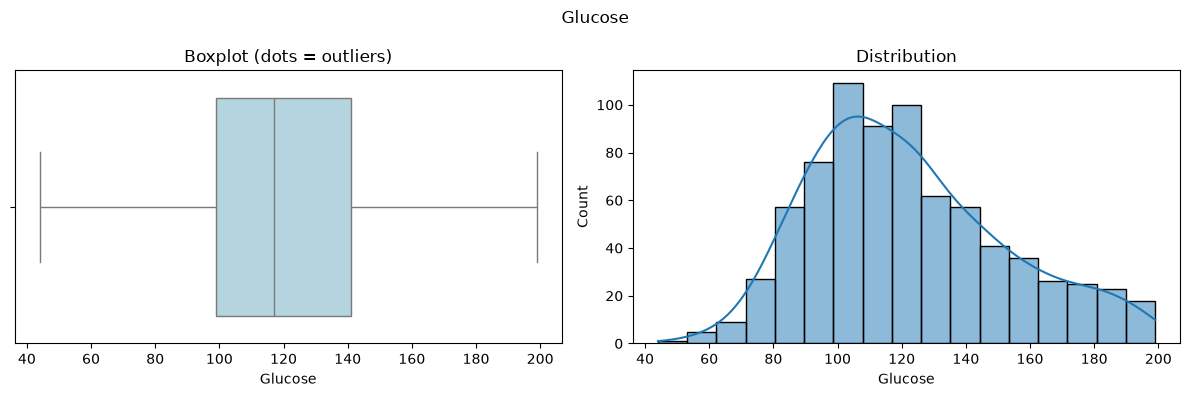

In [96]:
graphe_check_outliers(df, "Glucose")

In [97]:
missing = df["Glucose"].isna()
df.groupby(missing)[["BMI", "Age", "BloodPressure"]].median()

,BMI,Age,BloodPressure
Glucose,,,
False,32.0,29.0,72.0
True,32.0,22.0,68.0


In [98]:
df = handle_missing(df, "Glucose")
column_info(df, "Glucose")

,Section,Metric,Value
0,General,Data type,float64
1,General,Total rows,768
2,General,Unique values,135
3,Quality,Missing (NaN),0 (0.0%)
4,Quality,Zeros,0 (0.0%)
5,Distribution,Min,44.0
6,Distribution,Max,199.0
7,Distribution,Mean,121.66
8,Distribution,Median,117.0
9,Distribution,Std deviation,30.44
